# Pharmacophore-Guided Scaffold Hopping

This notebook demonstrates a pharmacophore-guided scaffold hopping workflow for identifying and generating structurally diverse analogs while preserving key molecular interactions.

#### Workflow Overview

**1. Setup** :Define the reference molecule and the query scaffold to be evaluated for scaffold replacement.

**2. Initial Pharmacophore Matching**:Extract pharmacophore features from both molecules, construct pharmacophore graphs, and identify the best feature correspondences between the reference and scaffold molecules to establish anchor points.

**3. Pharmacophore Alignment**:Use the initial anchor matches to guide the search for an optimal pharmacophore alignment between the reference molecule and the query scaffold.

**4. Attachment Point Identification**:Determine suitable attachment points on the aligned scaffold based on the geometry and connectivity of the reference structure.

**5. Molecule Generation**:Replace the selected scaffold region, attach the retained fragments to the new scaffold, and sanitize the generated molecule.

#### Notebook Outputs

**1. Pharmacophore-Guided Replacement Region Identification**:Identification of scaffold regions suitable for replacement using pharmacophore alignment and feature mapping.

**2. Scaffold-Hopped Molecule Generation**:Generation of new molecule following scaffold replacement.

**3. Evaluation Metrics**:Calculation of structural and alignment metrics such as:
- RMSD
- Query coverage
- Ref_Query aligned images



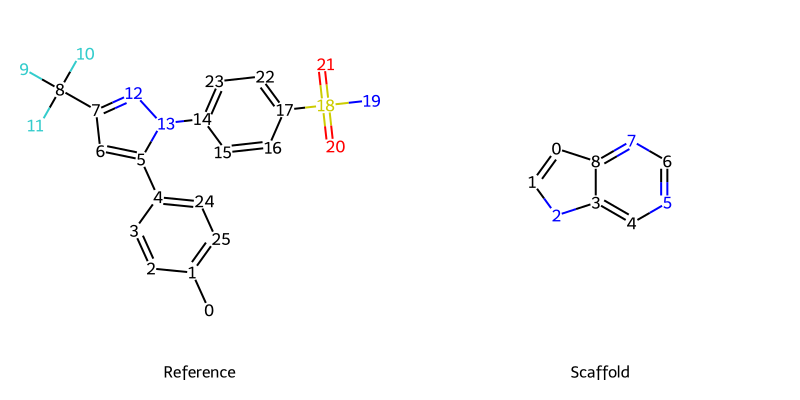

In [1]:
# Visualize reference molecule and query scaffold
from rdkit import Chem
from rdkit.Chem import Draw

# ref_smiles - Smiles of the molecule for scaffold replacement
# scaffold_smiles - Smiles of the scaffold that is replacing the ideal region in the reference
ref_smiles      = "Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1"
scaffold_smiles = "C1=CNC2=CN=CN=C21"

# ref_smiles      = "O=C1C=C(OCC2=NC=C2)C=CN1C3=CC4=C(N(CCN(C(C)C)CC5)C5=C4)C=C3"
# scaffold_smiles = "c1cc2cc(OC3CCSC3)ccc2[nH]1"=C(Cl)C


def mol_with_atom_indices(smiles):
    """Add atom indices as labels for visualization."""
    mol = Chem.MolFromSmiles(smiles)
    for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", str(atom.GetIdx()))
    return mol

ref_mol = mol_with_atom_indices(ref_smiles)
query_mol = mol_with_atom_indices(scaffold_smiles)

img = Draw.MolsToGridImage(
    [ref_mol, query_mol],
    molsPerRow=2,
    subImgSize=(400, 400),
    legends=["Reference", "Scaffold"]
)

img

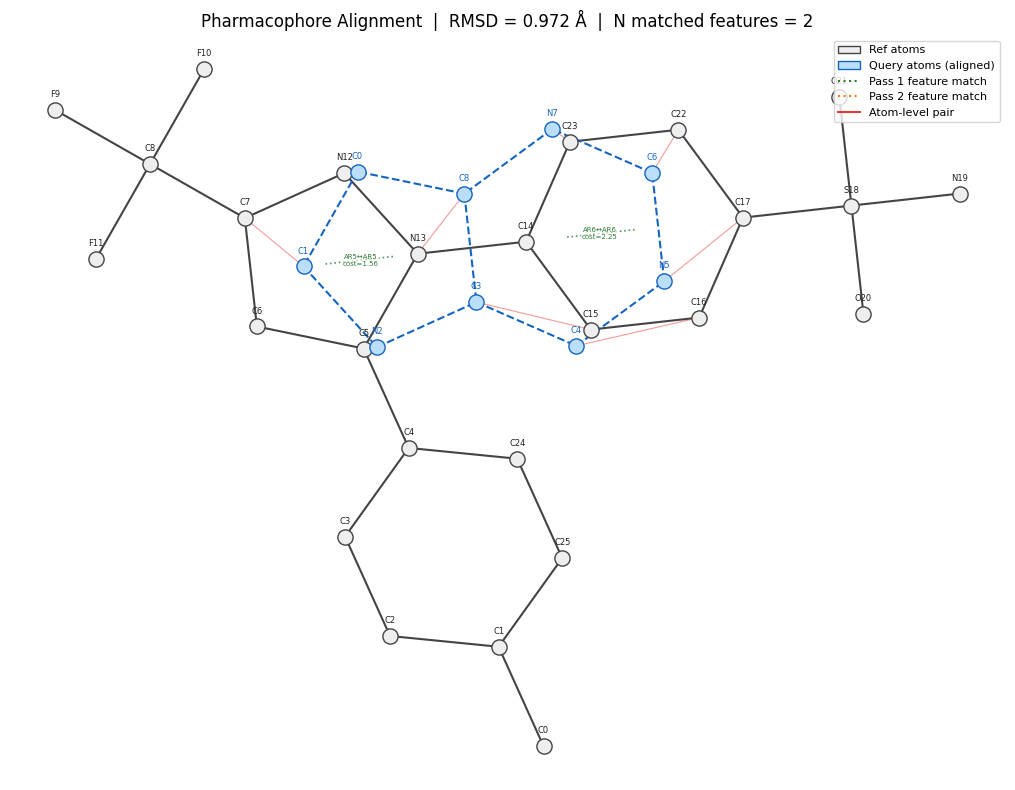

Saved to alignment.png

ATOM ALIGNMENT REPORT (deduplicated)

  Feature match: ref_node=4 (AR5) ↔ query_node=3 (AR5)  [Pass 1]
    ref atom   5 (C) ↔ query atom   2 (N)  dist = 0.184 Å
    ref atom  12 (N) ↔ query atom   0 (C)  dist = 0.184 Å
    ref atom   7 (C) ↔ query atom   1 (C)  dist = 1.046 Å
    ref atom  13 (N) ↔ query atom   8 (C)  dist = 1.046 Å

  Feature match: ref_node=6 (AR6) ↔ query_node=4 (AR6)  [Pass 1]
    ref atom  23 (C) ↔ query atom   7 (N)  dist = 0.300 Å
    ref atom  22 (C) ↔ query atom   6 (C)  dist = 0.693 Å
    ref atom  17 (C) ↔ query atom   5 (N)  dist = 1.393 Å
    ref atom  15 (C) ↔ query atom   3 (C)  dist = 1.617 Å
    ref atom  16 (C) ↔ query atom   4 (C)  dist = 1.734 Å

  Overall centroid RMSD: 0.9723 Å

REPLACEABLE REGION
  Matched ref atoms  : [5, 7, 12, 13, 15, 16, 17, 22, 23]
  Replaceable atoms  : [5, 6, 7, 12, 13, 14, 15, 16, 17, 22, 23]
  Boundary atoms     : [5, 7, 17]
  Boundary→Query map : {5: 2, 7: 1, 17: 5}
  Coverage of Query    : 40.00

In [2]:
import utils
import importlib
importlib.reload(utils)
from utils import *

from rdkit import Chem
from rdkit.Chem import Draw

ph1_result = ph_similarity_pipeline(
    ref_smiles=ref_smiles,
    query_smiles=scaffold_smiles,

)
# After align_and_visualize
align_result = align_and_visualize(
    pipeline_result = ph1_result,
    ref_smiles = ref_smiles,    
    query_smiles = scaffold_smiles,
    output_path    = "alignment.png",
)
R, t, atom_mapping, rmsd, query_coords_aligned, region_info = align_result



# Step 2 — build mol objects (same ones used inside align_and_visualize)
ref_mol   = Chem.MolFromSmiles(ref_smiles)
query_mol = Chem.MolFromSmiles(scaffold_smiles)
AllChem.Compute2DCoords(ref_mol)
AllChem.Compute2DCoords(query_mol)

# Step 3 — everything you need is now available
hopped_mol_smi, attachment_log, failed_log = build_hopped_scaffold(
    align_result         = (R, t, atom_mapping, rmsd, region_info),
    region_info          = region_info,
    ref_mol              = ref_mol,
    query_mol            = query_mol,
    query_coords_aligned = query_coords_aligned,
)



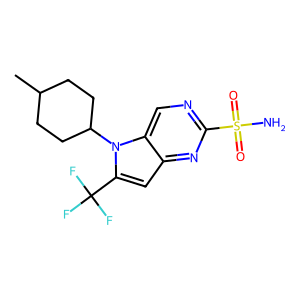

In [3]:
Draw.MolToImage(Chem.MolFromSmiles(hopped_mol_smi))